In [9]:
import pandas as pd
from sklearn.metrics import mean_squared_error, mean_absolute_error
from matplotlib import pyplot as plt

from xgboost import XGBRegressor
from sklearn.model_selection import TimeSeriesSplit
import numpy as np
import itertools

# Example: Q_MAX river flow
q_min = pd.read_csv("q_min.csv")

# Optional: clean column names
q_min.columns = q_min.columns.str.strip().str.lower()

def prepare_time_series(df, value_name='flow'):
    months = ["jan","feb","mar","apr","maj","jun","jul","avg","sep","okt","nov","dec"]
    existing_months = [m for m in months if m in df.columns]

    # Convert to numeric and fill missing
    df[existing_months] = df[existing_months].apply(pd.to_numeric, errors='coerce')
    df[existing_months] = df[existing_months].fillna(method='ffill').fillna(method='bfill')

    # Melt to long format
    ts = df.melt(id_vars='year', value_vars=existing_months, var_name='month', value_name=value_name)
    ts['date'] = pd.to_datetime(ts['year'].astype(str) + '-' + ts['month'], format='%Y-%b', errors='coerce')
    ts = ts.dropna(subset=['date'])
    ts = ts.set_index('date').sort_index()
    ts = ts.dropna(subset=[value_name])
    
    # Ensure non-negative
    ts[value_name] = ts[value_name].clip(lower=0)
    
    return ts


def prepare_ml_data(ts, window_size=12, split_date='2014-01-01'):
    
    ts = ts.copy()
    ts['flow'] = ts['flow'].clip(lower=0)

    # Seasonal encoding
    ts['sin_month'] = np.sin(2 * np.pi * ts.index.month / 12)
    ts['cos_month'] = np.cos(2 * np.pi * ts.index.month / 12)

    flows = ts['flow'].values
    sin_m = ts['sin_month'].values
    cos_m = ts['cos_month'].values
    dates = ts.index

    X, y, idx = [], [], []
    for i in range(window_size, len(flows)):
        lag_vals = flows[i-window_size:i]
        features = np.concatenate([lag_vals, [sin_m[i], cos_m[i]]])
        
        X.append(features)
        y.append(flows[i])
        idx.append(dates[i])

    X = np.array(X)
    y = np.array(y)
    idx = pd.to_datetime(idx)

    # Log transform
    y_log = np.log1p(y)

    # Train/test split
    split_date = pd.to_datetime(split_date)
    split_idx = np.where(idx < split_date)[0]
    split = split_idx[-1] + 1 if len(split_idx) > 0 else 0

    return {
        "X_train": X[:split],
        "y_train": y_log[:split],
        "X_test": X[split:],
        "y_test": y[split:],        # original scale
        "idx_test": idx[split:]
    }

def nse(y_true, y_pred):
    """Nash-Sutcliffe Efficiency"""
    denom = np.sum((y_true - np.mean(y_true))**2)
    if denom == 0:
        return 0
    return 1 - np.sum((y_true - y_pred)**2) / denom

def compute_metrics(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    nse = 1 - np.sum((y_true - y_pred)**2) / np.sum((y_true - np.mean(y_true))**2)
    return rmse, mae, nse

In [10]:
from sklearn.ensemble import RandomForestRegressor

def tune_rf(X_train, y_train):

    param_grid = {
        'n_estimators': [200, 500],
        'max_depth': [5, 8, 12],
        'min_samples_split': [2, 5],
        'min_samples_leaf': [1, 2],
        'max_features': [0.6, 0.8]
    }

    tscv = TimeSeriesSplit(n_splits=5)

    best_score = -np.inf
    best_params = None

    for n_est, max_d, min_split, min_leaf, max_feat in itertools.product(
        param_grid['n_estimators'],
        param_grid['max_depth'],
        param_grid['min_samples_split'],
        param_grid['min_samples_leaf'],
        param_grid['max_features']
    ):

        scores = []

        for train_idx, val_idx in tscv.split(X_train):

            X_tr, X_val = X_train[train_idx], X_train[val_idx]
            y_tr, y_val = y_train[train_idx], y_train[val_idx]

            model = RandomForestRegressor(
                n_estimators=n_est,
                max_depth=max_d,
                min_samples_split=min_split,
                min_samples_leaf=min_leaf,
                max_features=max_feat,
                random_state=42,
                n_jobs=-1
            )

            model.fit(X_tr, y_tr)

            # log → original
            y_pred = np.expm1(model.predict(X_val))
            y_true = np.expm1(y_val)

            score = nse(y_true, y_pred)
            scores.append(score)

        avg_score = np.mean(scores)

        if avg_score > best_score:
            best_score = avg_score
            best_params = (n_est, max_d, min_split, min_leaf, max_feat)

    print("\nBest RF params (CV NSE):", best_score)
    print("Params:", best_params)

    # ✅ Train final model
    best_model = RandomForestRegressor(
        n_estimators=best_params[0],
        max_depth=best_params[1],
        min_samples_split=best_params[2],
        min_samples_leaf=best_params[3],
        max_features=best_params[4],
        random_state=42,
        n_jobs=-1
    )

    best_model.fit(X_train, y_train)

    return best_model

In [11]:
def test_rf_with_config(model, data):

    X_test  = data["X_test"]
    y_test  = data["y_test"]
    idx     = data["idx_test"]

    # Predict
    y_pred = np.expm1(model.predict(X_test))

    # Safety
    y_pred = np.maximum(y_pred, 0)

    # Align
    min_len = min(len(y_test), len(y_pred))
    y_test = y_test[:min_len]
    y_pred = y_pred[:min_len]
    idx = idx[:min_len]

    # Metrics
    rmse, mae, nse_val = compute_metrics(y_test, y_pred)

    print("\n==============================")
    print(f"Random Forest (Tuned)")
    print("==============================")
    print(f"RMSE: {rmse:.2f}")
    print(f"MAE : {mae:.2f}")
    print(f"NSE : {nse_val:.4f}")

    # Plot
    plt.figure(figsize=(14,5))
    plt.plot(idx, y_test, label='Actual')
    plt.plot(idx, y_pred, label='RF Tuned', marker='x')
    plt.title("RF Prediction (2014–2025)")
    plt.xlabel("Date")
    plt.ylabel("Flow")
    plt.legend()
    plt.grid(True)
    plt.show()

    return y_pred


Best RF params (CV NSE): 0.48980212428964565
Params: (500, 8, 5, 1, 0.6)

Random Forest (Tuned)
RMSE: 26.56
MAE : 19.72
NSE : 0.4198


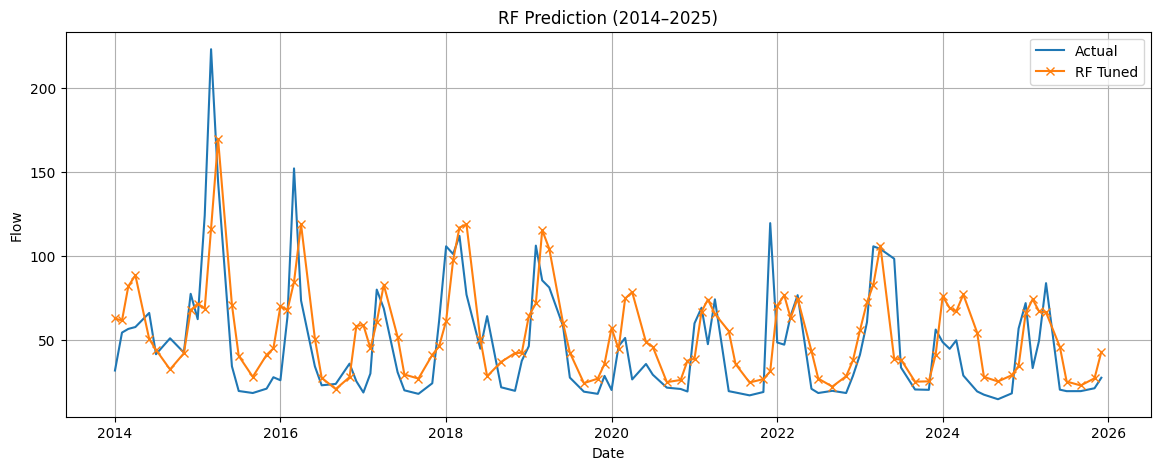

array([ 62.59775145,  61.39972568,  81.8371696 ,  88.33571415,
        50.3946807 ,  43.94390596,  32.23421648,  41.87276456,
        67.50212019,  71.4693317 ,  68.44370439, 116.14083135,
       169.2817517 ,  70.78452192,  40.33492035,  27.84055988,
        40.93667005,  44.75908661,  69.91448537,  67.57236091,
        84.4120125 , 118.61352726,  50.67003759,  27.25383102,
        20.54223553,  27.65334823,  58.09083154,  58.72673087,
        44.83641866,  60.48248941,  82.67767185,  51.65474369,
        29.21187061,  26.79333034,  40.90341814,  46.00315527,
        61.03172484,  97.2636885 , 116.79570677, 118.6128109 ,
        50.38699211,  28.17881822,  36.74622741,  42.0041711 ,
        42.1668346 ,  64.06492002,  71.56731142, 115.25012571,
       104.20998258,  59.85756296,  42.30385464,  24.0770813 ,
        26.75848901,  35.54513067,  56.93793867,  44.29150711,
        74.50235423,  78.33409881,  48.47894167,  45.71866759,
        24.6857482 ,  25.97010185,  37.45445162,  38.69

In [12]:
# Example: Q_MAX river flow
q_min = pd.read_csv("q_min.csv")

# Optional: clean column names
q_min.columns = q_min.columns.str.strip().str.lower()

ts_qmin = prepare_time_series(q_min)
data = prepare_ml_data(ts_qmin)

## train-test split 
X_train = data["X_train"]
y_train = data["y_train"]

X_test  = data["X_test"]
y_test  = data["y_test"]
idx     = data["idx_test"]

model = tune_rf(X_train, y_train)
test_rf_with_config(model, data)
